In [1]:
!pwd

/mnt/c/Users/vvasileiou/Desktop/lncAPNet/Pilot_2_Prostate/notebooks/Post-hoc_Analysis


In [2]:
# Libraries
import numpy as np
import re
import pandas as pd
from sklearn.preprocessing import KBinsDiscretizer
import networkx as nx
from adjustText import adjust_text
import openpyxl

import gc
import re
import random
import math

import stringdb
import string
import logging

import matplotlib.pyplot as plt
from matplotlib.image import imread
import matplotlib.colors as mcolors
import seaborn as sns
from matplotlib.colors import Normalize, LinearSegmentedColormap

from scipy.cluster.hierarchy import linkage, leaves_list
import igraph as ig
import leidenalg


import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from scipy.cluster.hierarchy import linkage, leaves_list

In [3]:
gc.collect()

# Biological priors with learning weights after supervised clustering
sc1_go = pd.read_excel("../../PASNet/Output/GO/sc1_weights.xlsx", index_col=0)
pt = pd.read_excel("../../PASNet/Input/GO/pt_fixed_ens.xlsx", index_col=0)

sc1_go.columns = pt.columns
sc1_go.index = pt.index

### data pre-processing to obtain the actual sc1_weights
data = []
for pathway, series in sc1_go.iterrows():
    for gene, value in series.items():
        data.append([pathway, gene, value])

# PASNet outputs (source:pathway; target:protein; Weight:learning weights from PASNet)
df_go = pd.DataFrame(data, columns=['source', 'target', 'Weight'])
df_go = df_go[df_go['Weight'] != 0]

gc.collect()

# Biological priors with learning weights after supervised clustering
sc1_rest = pd.read_excel("../../PASNet/Output/REST/sc1_weights.xlsx", index_col=0)
pt = pd.read_excel("../../PASNet/Input/REST/pt_fixed_ens.xlsx", index_col=0)

sc1_rest.columns = pt.columns
sc1_rest.index = pt.index

### data pre-processing to obtain the actual sc1_weights
data = []
for pathway, series in sc1_rest.iterrows():
    for gene, value in series.items():
        data.append([pathway, gene, value])

# PASNet outputs (source:pathway; target:protein; Weight:learning weights from PASNet)
df_rest = pd.DataFrame(data, columns=['source', 'target', 'Weight'])
df_rest = df_rest[df_rest['Weight'] != 0]

In [4]:
pasnet_genes_go = df_go['target'].unique()
print(len(pasnet_genes_go))

pasnet_genes_rest = df_rest['target'].unique()
print(len(pasnet_genes_rest))

1756
1490


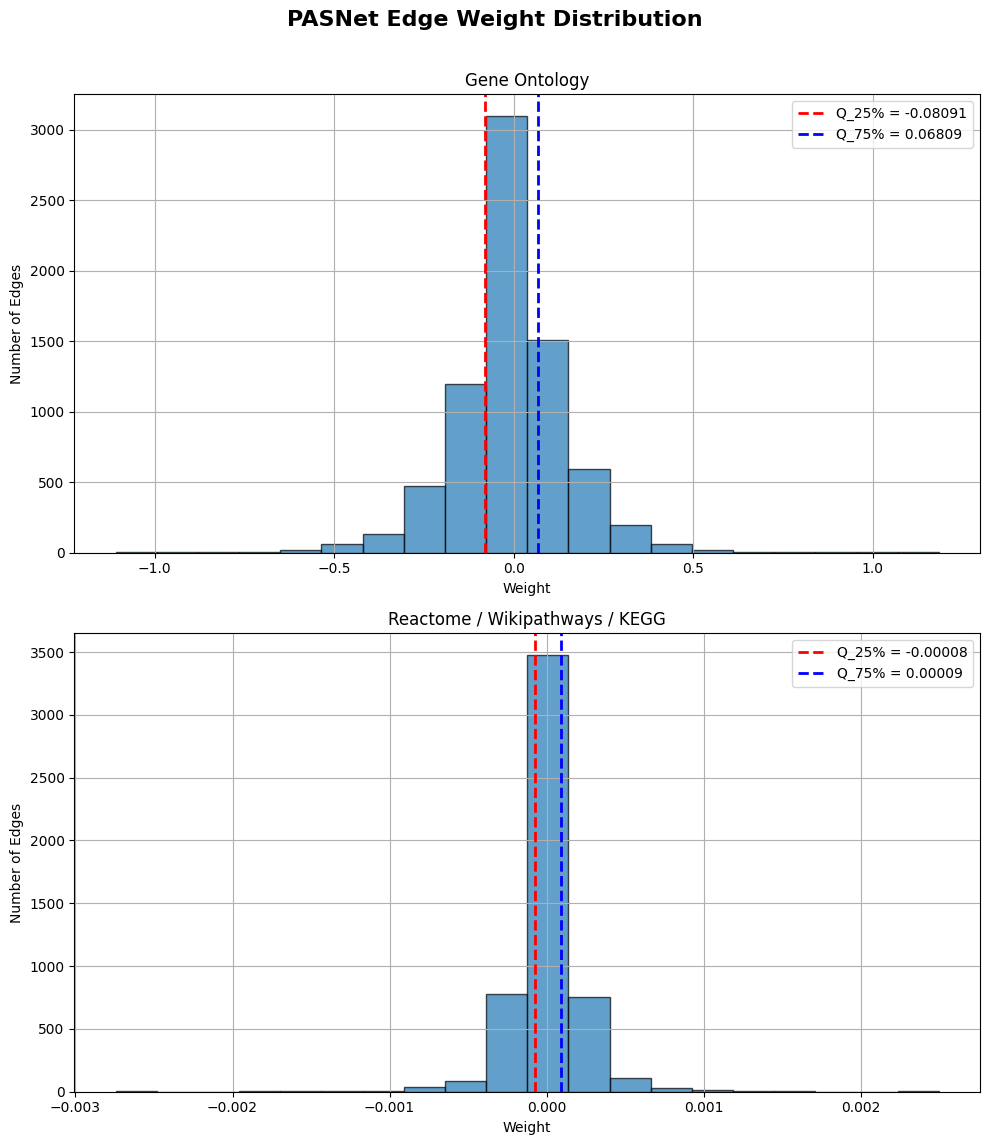

In [5]:
import matplotlib.pyplot as plt

# Gene Ontology weights
weight_go = df_go['Weight']
q1_go = weight_go.quantile(0.25)
q3_go = weight_go.quantile(0.75)

# Reactome/Wikipathways/KEGG weights
weight_rest = df_rest['Weight']
q1_rest = weight_rest.quantile(0.25)
q3_rest = weight_rest.quantile(0.75)

# Create 2x1 subplot (stacked vertically)
fig, axes = plt.subplots(2, 1, figsize=(10, 12), sharex=False)

# Add overall figure title (multipanel title)
fig.suptitle('PASNet Edge Weight Distribution', fontsize=16, fontweight='bold', y=0.95)

# Plot Gene Ontology histogram
axes[0].hist(weight_go, bins=20, edgecolor='black', alpha=0.7)
axes[0].axvline(x=q1_go, color='red', linestyle='--', linewidth=2, label=f'Q_25% = {q1_go:.5f}')
axes[0].axvline(x=q3_go, color='blue', linestyle='--', linewidth=2, label=f'Q_75% = {q3_go:.5f}')
axes[0].set_title('Gene Ontology')
axes[0].set_xlabel('Weight')
axes[0].set_ylabel('Number of Edges')
axes[0].grid(True)
axes[0].legend()

# Plot Reactome/Wikipathways/KEGG histogram
axes[1].hist(weight_rest, bins=20, edgecolor='black', alpha=0.7)
axes[1].axvline(x=q1_rest, color='red', linestyle='--', linewidth=2, label=f'Q_25% = {q1_rest:.5f}')
axes[1].axvline(x=q3_rest, color='blue', linestyle='--', linewidth=2, label=f'Q_75% = {q3_rest:.5f}')
axes[1].set_title('Reactome / Wikipathways / KEGG')
axes[1].set_xlabel('Weight')
axes[1].set_ylabel('Number of Edges')
axes[1].grid(True)
axes[1].legend()

plt.tight_layout(rect=[0, 0, 1, 0.94])  # leave space for suptitle
plt.savefig('../../figures/edge_weight_distribution.png', dpi=300)  # Save as high-res PNG
plt.show()

In [6]:
df_go = df_go[(df_go['Weight'] > q3_go) | (df_go['Weight'] < q1_go)]
df_rest = df_rest[(df_rest['Weight'] > q3_rest) | (df_rest['Weight'] < q1_rest)]

In [7]:
shap_validation_go = pd.read_csv("../../PASNet/Output/GO/feature_importance_table.csv", index_col=0)
shap_validation_go_top50 = shap_validation_go.sort_values(by="Importance", ascending=False).head(50)

shap_validation_rest = pd.read_csv("../../PASNet/Output/REST/feature_importance_table.csv", index_col=0)
shap_validation_rest_top50 = shap_validation_rest.sort_values(by="Importance", ascending=False).head(50)

In [8]:
# Step 1: Get the feature names (index) from both DataFrames
features_rest = shap_validation_rest_top50.index
features_go = shap_validation_go_top50.index

# Step 2: Combine the feature names
combined_features = features_rest.to_list() + features_go.to_list()

# Step 3: Remove duplicates
unique_features = pd.Index(combined_features).unique()

# Optional: Convert to DataFrame if needed
features_df = pd.DataFrame(unique_features, columns=['Feature'])

In [9]:
# Assuming your DataFrame is called df
table_go = df_go.pivot_table(
    index='source',      # rows
    columns='target',    # columns
    values='Weight',     # values to fill
    fill_value=0         # fill missing with 0
)

# Optional: reset column names if needed
table_go = table_go.reset_index()

# Assuming your DataFrame is called df
table_rest = df_rest.pivot_table(
    index='source',      # rows
    columns='target',    # columns
    values='Weight',     # values to fill
    fill_value=0         # fill missing with 0
)

# Optional: reset column names if needed
table_rest = table_rest.reset_index()

In [10]:
def filter_table(table, features_df):
    # Set 'source' as index if not already
    table_indexed = table.set_index('source')
    
    # Keep only columns present in features_df['Feature']
    filtered_table = table_indexed[table_indexed.columns.intersection(features_df['Feature'])]
    
    # Keep only rows where the sum across columns is not 0
    filtered_table = filtered_table[filtered_table.sum(axis=1) != 0]
    
    # Reset index to bring 'source' back as a column
    return filtered_table.reset_index()

# Apply the function to both tables
filtered_table_go = filter_table(table_go, features_df)
filtered_table_rest = filter_table(table_rest, features_df)

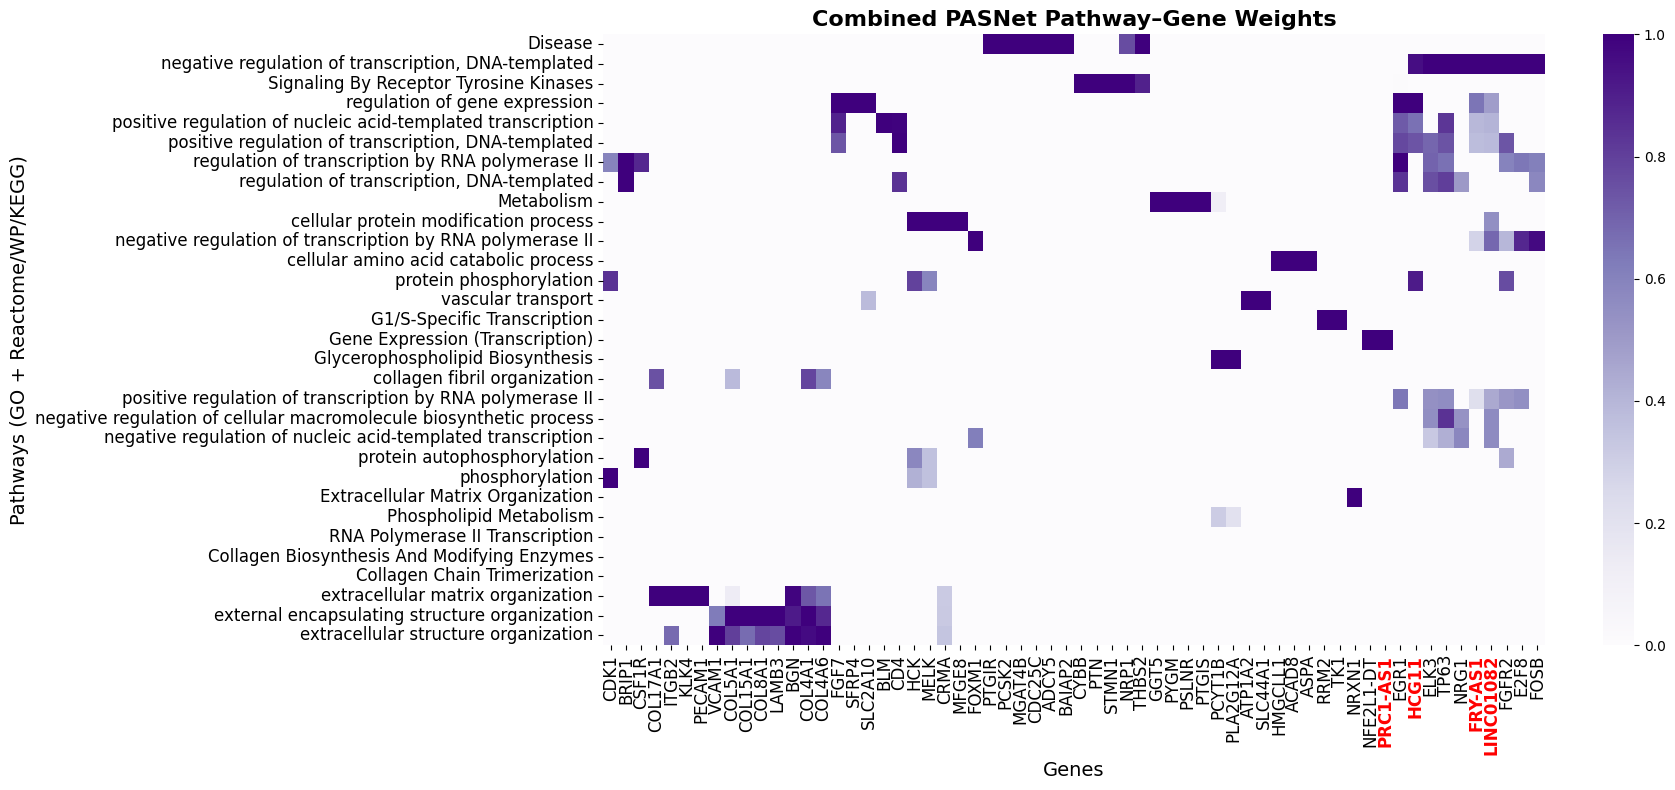

In [11]:
# --- Example test genes ---
test_genes = ["PRC1-AS1", "LINC01088", "FRY-AS1", "HLA-DQB1-AS1", "LINC01082", "HCG11"]

# ===============================================================
# 1. Combine GO and Rest tables first
# ===============================================================
combined = pd.concat([filtered_table_go, filtered_table_rest], ignore_index=True)

# ===============================================================
# 2. Fill missing gene values with 0 (numeric columns only)
# ===============================================================
numeric_cols = combined.columns.difference(['source'])
combined[numeric_cols] = combined[numeric_cols].fillna(0)

# ===============================================================
# 3. Take absolute values
# ===============================================================
combined[numeric_cols] = combined[numeric_cols].abs()

# ===============================================================
# 4. Filter rows and columns
# ===============================================================
def filter_rows_cols(df, min_nonzero_rows=2, min_nonzero_cols=1):
    df = df.copy()
    # Keep pathways with >= min_nonzero_rows non-zero genes
    df = df[df[numeric_cols].gt(0).sum(axis=1) >= min_nonzero_rows]
    # Keep genes present in >= min_nonzero_cols pathways
    nonzero_genes = df[numeric_cols].gt(0).sum(axis=0) >= min_nonzero_cols
    df = pd.concat([df[['source']], df[numeric_cols].loc[:, nonzero_genes]], axis=1)
    return df

combined = filter_rows_cols(combined, min_nonzero_rows=3, min_nonzero_cols=1)

# ===============================================================
# 5. Recompute numeric_cols after filtering
# ===============================================================
numeric_cols = combined.columns.difference(['source'])

# ===============================================================
# 6. Clean pathway/source names
# ===============================================================
def clean_source_names(df):
    df = df.copy()
    df['source'] = df['source'].str.replace(r"\s*\(GO:[^)]+\)", "", regex=True)
    df['source'] = df['source'].str.replace(r"\s*R-HSA-\d+$", "", regex=True)
    df['source'] = df['source'].str.replace(r"\s*WP\d+$", "", regex=True)
    return df

combined = clean_source_names(combined)
combined_for_next_steps = combined

# Shorten long pathway names
combined['source'] = combined['source'].replace(
    "Diseases Of Signal Transduction By Growth Factor Receptors And Second Messengers",
    "Signal Transduction By Growth Factor Receptors, Second Messengers"
)

# ===============================================================
# 7. Normalize numeric values (Min–Max scaling 0–1)
# ===============================================================
def scale_dataframe(df, feature_range=(0, 1)):
    data = df[numeric_cols]
    scaler = MinMaxScaler(feature_range=feature_range)
    scaled = pd.DataFrame(scaler.fit_transform(data), columns=data.columns, index=df.index)
    df_scaled = pd.concat([df[['source']], scaled], axis=1)
    return df_scaled

combined = scale_dataframe(combined)

# ===============================================================
# 8. Hierarchical clustering function
# ===============================================================
def cluster_dataframe(df):
    data = df[numeric_cols]
    # Cluster rows (pathways)
    row_linkage = linkage(data, method='average', metric='euclidean')
    row_order = leaves_list(row_linkage)
    # Cluster columns (genes)
    col_linkage = linkage(data.T, method='average', metric='euclidean')
    col_order = leaves_list(col_linkage)
    # Reorder dataframe
    clustered_df = df.iloc[row_order, :]
    clustered_df = clustered_df.iloc[:, [0] + (col_order + 1).tolist()]
    return clustered_df

clustered_combined = cluster_dataframe(combined)

# ===============================================================
# 9. Highlight function for test genes
# ===============================================================
def color_xticklabels(ax, test_genes):
    for tick in ax.get_xticklabels():
        if tick.get_text() in test_genes:
            tick.set_color('red')
            tick.set_fontweight('bold')
        else:
            tick.set_color('black')
            tick.set_fontweight('normal')
    ax.tick_params(axis='x', rotation=90)

# ===============================================================
# 10. Plot combined clustered heatmap
# ===============================================================
plt.figure(figsize=(18, 8))
sns.heatmap(
    clustered_combined.set_index('source'),
    cmap='Purples',
    annot=False,
    yticklabels=True
)
plt.title('Combined PASNet Pathway–Gene Weights', fontsize=16, fontweight='bold')
plt.xlabel('Genes', fontsize=14)
plt.ylabel('Pathways (GO + Reactome/WP/KEGG)', fontsize=14)
plt.xticks(fontsize=12, rotation=90)
plt.yticks(fontsize=12)

ax = plt.gca()
color_xticklabels(ax, test_genes)

plt.tight_layout()
plt.savefig("../../figures/Hierarchical_heatmap_prostate.png", dpi=300, bbox_inches='tight')
plt.show()


In [12]:
pathways = clustered_combined['source'].tolist()
gene_list = sorted(set(clustered_combined.columns[1:].tolist()))

print(len(pathways))
print(len(gene_list))

31
62


In [13]:
# First, ensure 'source' is the index if not already
combined_for_next_steps_temp = combined_for_next_steps.set_index('source')

# Reset index so that the rownames become a column
df_reset = combined_for_next_steps_temp.reset_index()

# Melt the dataframe
long_df = df_reset.melt(id_vars='source', var_name='column_name', value_name='value')

# Rename columns if you want specific names
long_df = long_df.rename(columns={'source': 'row_name'})

long_df = df_reset.melt(id_vars='source', var_name='target', value_name='weights')

long_df = long_df[long_df['weights'] != 0]

combined_df = long_df

combined_df['MI'] = None
combined_df['spearman'] = None
combined_df['p-value'] = None

In [14]:
## NetBID2 results

In [15]:
res_tcga = pd.read_excel("../../results/TCGA/TCGA_NetBID2_ms_tab.xlsx")
res_tcga = res_tcga[['originalID', 'funcType', 'Size',
                     'logFC.U.Vs.M_DA', 'adj.P.Val.U.Vs.M_DA', 'Z.U.Vs.M_DA',
                     'logFC.U.Vs.M_DE', 'adj.P.Val.U.Vs.M_DE', 'Z.U.Vs.M_DE']]

res_tcga.rename(columns={
    'originalID': 'ID',
    'funcType': 'Type',
    'logFC.U.Vs.M_DA': 'logFC_DA',
    'adj.P.Val.U.Vs.M_DA': 'adj.P.Val_DA',
    'Z.U.Vs.M_DA': 'Z-score_DA',
    'logFC.U.Vs.M_DE': 'logFC_DE',
    'adj.P.Val.U.Vs.M_DE': 'adj.P.Val_DE',
    'Z.U.Vs.M_DE': 'Z-score_DE',
}, inplace=True)

# Create a temporary column to give priority to "TF" rows
res_tcga['priority'] = res_tcga['Type'].apply(lambda x: 0 if x == 'TF' else 1)

# Sort by priority and ID
res_tcga = res_tcga.sort_values(by=['priority', 'ID'])

# Drop duplicates, keeping TF first
res_tcga = res_tcga.drop_duplicates(subset='ID', keep='first')

# Drop helper column
res_tcga = res_tcga.drop(columns=['priority'])

# Apply filters
res_tcga_filt_overt = res_tcga[
    (res_tcga['adj.P.Val_DA'] < 0.05) &
    (res_tcga['adj.P.Val_DE'] < 0.05) &
    (res_tcga['Size'] > 30)
]

res_tcga_filt_hidden = res_tcga[
    (res_tcga['adj.P.Val_DA'] < 0.05) &
    (res_tcga['adj.P.Val_DE'] > 0.05) &
    (res_tcga['Size'] > 30)
]

# Print summary
print("Overt Drivers:", len(res_tcga_filt_overt))
print("Hidden Drivers:", len(res_tcga_filt_hidden))
print("Overt TFs:", len(res_tcga_filt_overt[res_tcga_filt_overt['Type'] == "TF"]))
print("Overt SIGs:", len(res_tcga_filt_overt[res_tcga_filt_overt['Type'] == "SIG"]))
print("Overt NCs:", len(res_tcga_filt_overt[res_tcga_filt_overt['Type'] == "NC"]))
print("Hidden TFs:", len(res_tcga_filt_hidden[res_tcga_filt_hidden['Type'] == "TF"]))
print("Hidden SIGs:", len(res_tcga_filt_hidden[res_tcga_filt_hidden['Type'] == "SIG"]))
print("Hidden NCs:", len(res_tcga_filt_hidden[res_tcga_filt_hidden['Type'] == "NC"]))

Overt Drivers: 2609
Hidden Drivers: 1722
Overt TFs: 380
Overt SIGs: 1283
Overt NCs: 946
Hidden TFs: 290
Hidden SIGs: 649
Hidden NCs: 783


/tmp/ipykernel_5791/2732470156.py:42: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Activity'] = df['logFC_DA'].apply(lambda x: 'Hyper' if x > 0 else 'Hypo')
/tmp/ipykernel_5791/2732470156.py:43: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['DriverClass'] = cls
/tmp/ipykernel_5791/2732470156.py:42: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.py

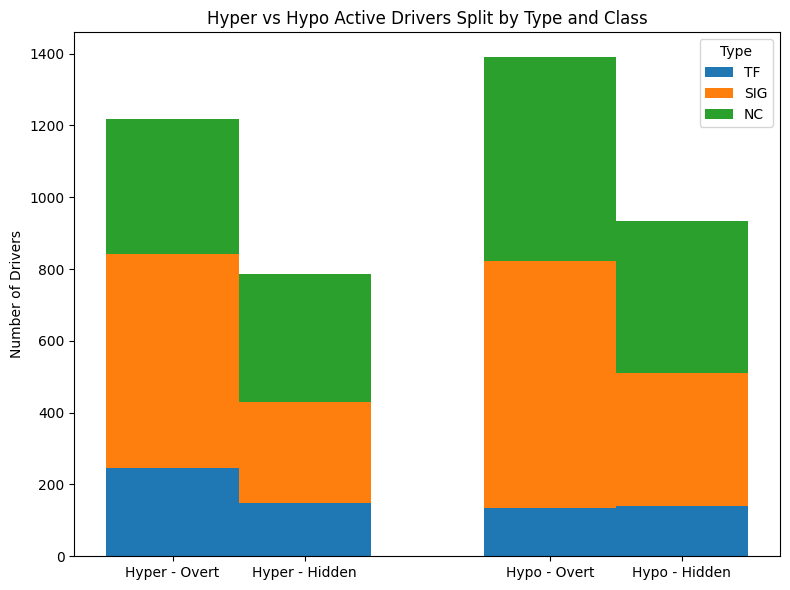

In [16]:
import pandas as pd
import matplotlib.pyplot as plt

# --- Load & format table ---
res_tcga = pd.read_excel("../../results/TCGA/TCGA_NetBID2_ms_tab.xlsx")
res_tcga = res_tcga[['originalID', 'funcType', 'Size',
                     'logFC.U.Vs.M_DA', 'adj.P.Val.U.Vs.M_DA', 'Z.U.Vs.M_DA',
                     'logFC.U.Vs.M_DE', 'adj.P.Val.U.Vs.M_DE', 'Z.U.Vs.M_DE']]

res_tcga.rename(columns={
    'originalID': 'ID',
    'funcType': 'Type',
    'logFC.U.Vs.M_DA': 'logFC_DA',
    'adj.P.Val.U.Vs.M_DA': 'adj.P.Val_DA',
    'Z.U.Vs.M_DA': 'Z-score_DA',
    'logFC.U.Vs.M_DE': 'logFC_DE',
    'adj.P.Val.U.Vs.M_DE': 'adj.P.Val_DE',
    'Z.U.Vs.M_DE': 'Z-score_DE',
}, inplace=True)

# --- Prioritize TF duplicates ---
res_tcga['priority'] = res_tcga['Type'].apply(lambda x: 0 if x == 'TF' else 1)
res_tcga = res_tcga.sort_values(by=['priority', 'ID'])
res_tcga = res_tcga.drop_duplicates(subset='ID', keep='first')
res_tcga.drop(columns=['priority'], inplace=True)

# --- Filtering Overt / Hidden ---
res_tcga_filt_overt = res_tcga[
    (res_tcga['adj.P.Val_DA'] < 0.05) &
    (res_tcga['adj.P.Val_DE'] < 0.05) &
    (res_tcga['Size'] > 30)
]

res_tcga_filt_hidden = res_tcga[
    (res_tcga['adj.P.Val_DA'] < 0.05) &
    (res_tcga['adj.P.Val_DE'] > 0.05) &
    (res_tcga['Size'] > 30)
]

# --- Classify Activity State ---
for df, cls in zip([res_tcga_filt_overt, res_tcga_filt_hidden], ['Overt', 'Hidden']):
    df['Activity'] = df['logFC_DA'].apply(lambda x: 'Hyper' if x > 0 else 'Hypo')
    df['DriverClass'] = cls

# --- Combine ---
res_plot = pd.concat([res_tcga_filt_overt, res_tcga_filt_hidden], ignore_index=True)

# --- Prepare counts ---
plot_counts = res_plot.groupby(['Activity', 'DriverClass', 'Type']).size().reset_index(name='Count')

# --- Plot stacked bars with horizontal Overt/Hidden labels ---
fig, ax = plt.subplots(figsize=(8,6))

types = ['TF', 'SIG', 'NC']
type_colors = {'TF':'#1f77b4','SIG':'#ff7f0e','NC':'#2ca02c'}

activities = ['Hyper','Hypo']
driver_classes = ['Overt','Hidden']
bar_width = 0.35
x_positions = [0,1]  # Hyper=0, Hypo=1

# Plot bars
for i, cls in enumerate(driver_classes):
    bottom_vals = [0,0]
    for t in types:
        counts = []
        for j, act in enumerate(activities):
            val = plot_counts[
                (plot_counts['Activity']==act) &
                (plot_counts['DriverClass']==cls) &
                (plot_counts['Type']==t)
            ]['Count'].values
            counts.append(val[0] if len(val)>0 else 0)
        ax.bar([xi + i*bar_width for xi in x_positions], counts, width=bar_width,
               bottom=bottom_vals, color=type_colors[t], label=t if i==0 else "")
        bottom_vals = [bottom_vals[j] + counts[j] for j in range(2)]

# --- X-axis labels as "Hyper - Overt", "Hyper - Hidden", etc ---
xticks = []
xticklabels = []
for j, act in enumerate(activities):
    for i, cls in enumerate(driver_classes):
        xticks.append(j + i*bar_width)
        xticklabels.append(f"{act} - {cls}")

ax.set_xticks(xticks)
ax.set_xticklabels(xticklabels, rotation=0)
ax.set_ylabel("Number of Drivers")
ax.set_title("Hyper vs Hypo Active Drivers Split by Type and Class")

# Legend for Type
handles, labels = ax.get_legend_handles_labels()
ax.legend(handles, labels, title="Type")

plt.tight_layout()
plt.savefig("../../figures/Hyper_Hypo_Drivers_prostate.png", dpi=300)
plt.show()


In [17]:
res_tcga_filt = res_tcga[
    res_tcga['ID'].isin(features_df['Feature']) &
    res_tcga['ID'].isin(gene_list)
]
len(res_tcga_filt)

59

In [18]:
### NETWORK ###

In [19]:
df_sj_sig = pd.read_csv("../../results/TCGA/SJARACNe_networks/output_sig_sjaracne_Prostate_NetBID2_out_.final/consensus_network_ncol_.txt", sep='\t')
df_sj_tf = pd.read_csv("../../results/TCGA/SJARACNe_networks/output_tf_sjaracne_Prostate_NetBID2_out_.final/consensus_network_ncol_.txt", sep='\t')
df_sj_nc = pd.read_csv("../../results/TCGA/SJARACNe_networks/output_nc_sjaracne_Prostate_NetBID2_out_.final/consensus_network_ncol_.txt", sep='\t')

# Row binding the two dataframes
df_sj = pd.concat([df_sj_sig, df_sj_tf, df_sj_nc], axis=0, ignore_index=True)

# Removing duplicates based on columns "source" and "target"
df_sj = df_sj.drop_duplicates(subset=['source', 'target'])

# Keep only the specified columns: source, label, MI, spearman, p-value
columns_to_keep = ['source', 'target', 'MI', 'spearman', 'p-value']
df_sj = df_sj[columns_to_keep]

#Harmonizing with PASNet outputs
df_sj['Weight'] = None
df_sj = df_sj[df_sj['p-value'] <= 0.05]

df_sj['sorted_pair'] = df_sj.apply(lambda row: tuple(sorted([row['source'], row['target']])), axis=1)
df_sj = df_sj.sort_values(by='MI', ascending=False).drop_duplicates(subset=['sorted_pair']).drop(columns=['sorted_pair'])

combined_df_sj = pd.concat([combined_df, df_sj], ignore_index=True)

/tmp/ipykernel_5791/4009358471.py:22: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  combined_df_sj = pd.concat([combined_df, df_sj], ignore_index=True)


In [20]:
# 1. Create weights_go_df
weights = combined_df_sj['source'].unique()
weights_df = pd.DataFrame({
    'ID': weights,
    'Type': "Pathway",
    'Size': np.nan,
    'logFC_DA': np.nan,
    'adj.P.Val_DA': np.nan,
    'Z-score_DA': np.nan,
    'logFC_DE': np.nan,
    'adj.P.Val_DE': np.nan,
    'Z-score_DE': np.nan
})

# Filter weights_go_df to keep only IDs that match go_pathways
weights_df_filtered = weights_df[
    weights_df['ID'].apply(lambda x: any(go in x for go in pathways))
]

# 3. Concatenate with res_icgc_filt
node_combined = pd.concat([res_tcga_filt, weights_df_filtered], ignore_index=True)
len(node_combined)

90

In [21]:
# Network Visualization

In [22]:
# Step 1: Read the DataFrame with the edge connections
df_edges = combined_df_sj

# Step 2: Read the DataFrame with node attributes
df_node_attributes = node_combined

df_edges = df_edges[df_edges['source'].isin(df_node_attributes['ID']) & df_edges['target'].isin(df_node_attributes['ID'])]

# Step 3: Create an undirected graph
G = nx.Graph()

# Step 4: Add edges to the graph
for index, row in df_edges.iterrows():
    source = row['source']
    target = row['target']
    attributes = row.drop(['source', 'target'])  # Extract edge attributes
    G.add_edge(source, target, **attributes)  # Add edge with attributes

# Step 5: Transfer node attributes
for index, row in df_node_attributes.iterrows():
    node_name = row['ID']
    if node_name in G.nodes:
        attributes = row.drop('ID')  # Remove the node name to keep only the attributes
        G.nodes[node_name].update(attributes)

# Add a new attribute 'label' with node names
for node in G.nodes:
    G.nodes[node]['label'] = str(node)  # Set 'label' attribute to node name (convert to string if needed)

print(f"Edges: {len(G.edges)}")
print(f"Nodes: {len(G.nodes)}")

Edges: 276
Nodes: 90


Looks like you are using a tranform that doesn't support FancyArrowPatch, using ax.annotate instead. The arrows might strike through texts. Increasing shrinkA in arrowprops might help.


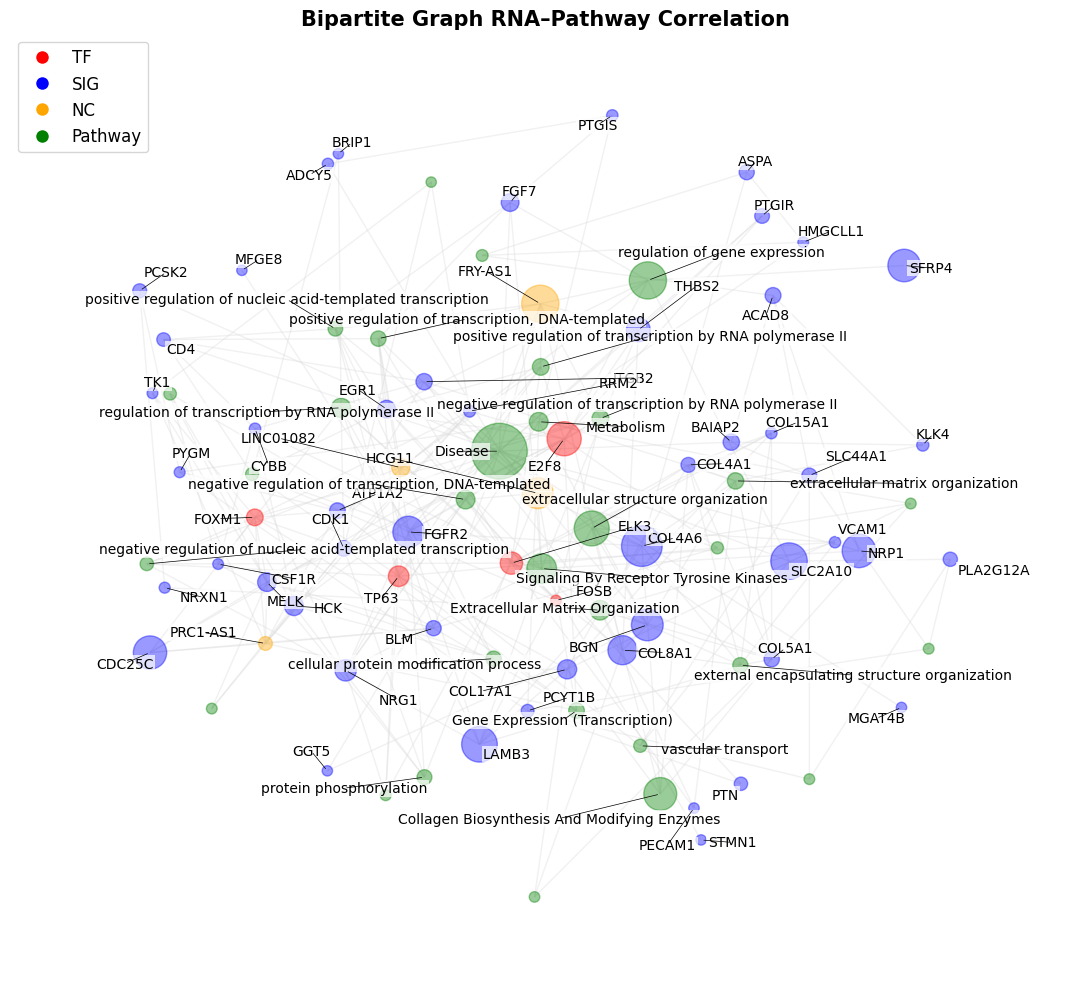

In [23]:
# Define the G object
F = G 

label_types = {'NC', 'TF', 'SIG'}
top_n_pathways = 20       # number of top pathways to label
min_degree_pathway = 2   # keep only pathways with >= 2 connections

# --- FUNCTIONS ---
def clean_label(label):
    """Remove pathway IDs or GO terms from label names for clarity."""
    patterns = [r'R-HSA-\d+', r'WP\d+', r'\(GO:\d+\)']
    for pattern in patterns:
        label = re.sub(pattern, '', label)
    return label.strip()

# --- FILTER PATHWAYS BY DEGREE ---
pathways_to_keep = [
    n for n in F.nodes()
    if F.nodes[n]['Type'] == 'Pathway' and F.degree(n) >= min_degree_pathway
]

# --- KEEP RELEVANT NODES (TF, SIG, NC + selected pathways) ---
nodes_to_keep = [
    n for n in F.nodes()
    if F.nodes[n]['Type'] in label_types or n in pathways_to_keep
]
F_filtered = F.subgraph(nodes_to_keep).copy()

# --- COMPUTE CENTRALITY ---
centrality = nx.betweenness_centrality(F_filtered, k=10, endpoints=True)

# --- SELECT TOP N PATHWAYS BY CENTRALITY ---
pathway_corr = {n: centrality[n] for n in F_filtered.nodes() if F_filtered.nodes[n]['Type'] == 'Pathway'}
top_pathways = sorted(pathway_corr, key=pathway_corr.get, reverse=True)[:top_n_pathways]

# --- CLEAN LABELS (TF, SIG, NC + TOP PATHWAYS) ---
cleaned_labels = {}
for node in F_filtered.nodes():
    if F_filtered.nodes[node]['Type'] in label_types or node in top_pathways:
        cleaned_labels[node] = clean_label(node)

# --- VISUALIZATION ---
pos = nx.spring_layout(F_filtered, k=0.8, seed=1234)

type_color_map = {'TF': 'red', 'SIG': 'blue', 'NC': 'orange', 'Pathway': 'green'}
node_color = [type_color_map.get(F_filtered.nodes[node]['Type'], 'grey') for node in F_filtered.nodes()]
node_size = [centrality[v] * 5000 for v in F_filtered.nodes()]

# --- PLOT GRAPH ---
fig, ax = plt.subplots(figsize=(11, 10))

nx.draw_networkx_nodes(F_filtered, pos=pos, node_color=node_color, node_size=node_size, alpha=0.4)
nx.draw_networkx_edges(F_filtered, pos=pos, edge_color="gainsboro", alpha=0.4)

# --- ADD LABELS ---
texts = []
for node, label in cleaned_labels.items():
    x, y = pos[node]
    text = ax.text(
        x, y, label,
        fontsize=10, color='black',
        ha='center', va='center',
        bbox=dict(facecolor='white', edgecolor='none', alpha=0.7, pad=1)
    )
    texts.append(text)

# Adjust labels to reduce overlap
adjust_text(
    texts,
    arrowprops=dict(arrowstyle='-', color='black', lw=0.5),
    expand_points=(1.3, 1.3),
    force_points=0.5,
    force_text=0.5
)

# --- LEGEND ---
handles = [plt.Line2D([0], [0], marker='o', color='w', markerfacecolor=color, markersize=10)
           for color in type_color_map.values()]
labels = list(type_color_map.keys())
ax.legend(handles=handles, labels=labels, loc='upper left', fontsize=12)

# --- TITLE & SAVE ---
plt.title("Bipartite Graph RNA–Pathway Correlation", fontsize=15, fontweight='bold')
ax.margins(0.1, 0.05)
fig.tight_layout()
plt.axis("off")
plt.savefig("../../figures/Main_Bipartite_graph_PRDA.png", dpi=300, bbox_inches='tight')
plt.show()

/tmp/ipykernel_5791/3646142567.py:102: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap('tab20', len(comm_ids))


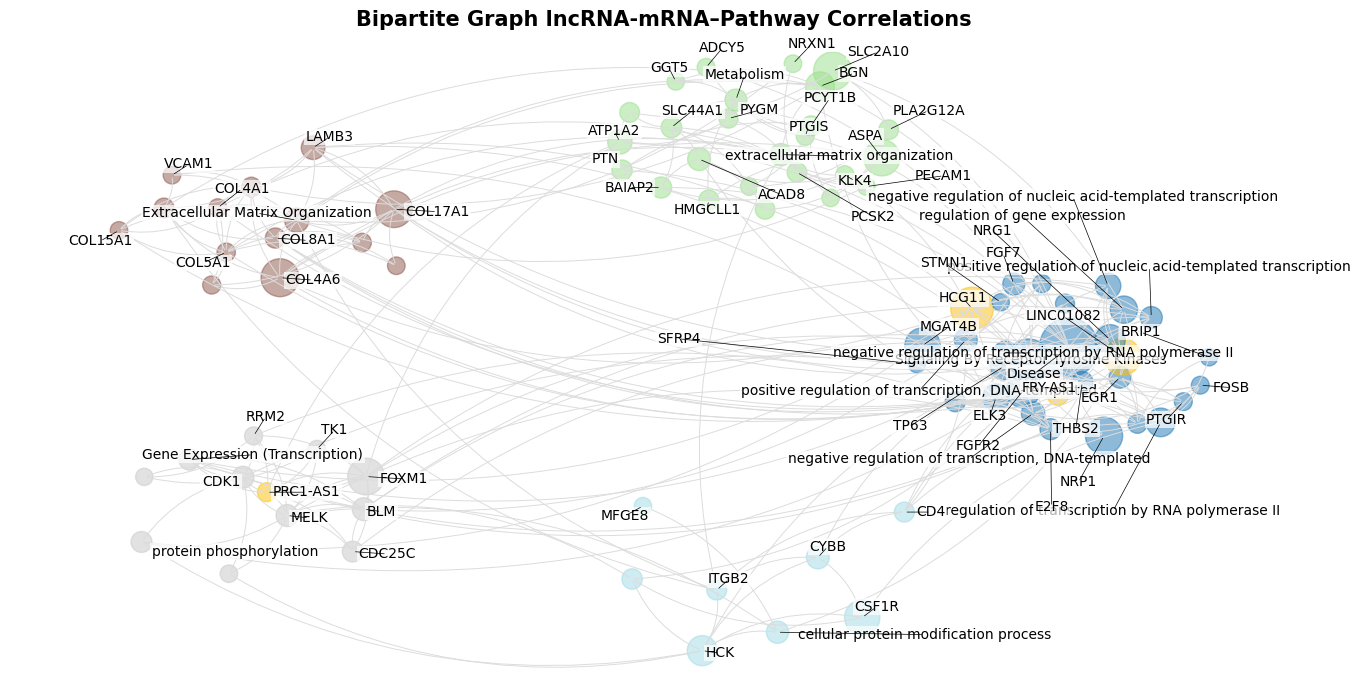

In [24]:
# --- SETUP ---
import re
import networkx as nx
import matplotlib.pyplot as plt
from adjustText import adjust_text
import numpy as np
import matplotlib.cm as cm

F = G  # your original graph
label_types = {'NC', 'TF', 'SIG'}
top_n_pathways = 15
min_degree_pathway = 2

# ---------------------
#  FUNCTIONS
# ---------------------
def clean_label(label):
    """Remove pathway IDs (Reactome, WikiPathways, GO)."""
    patterns = [r'R-HSA-\d+', r'WP\d+', r'\(GO:\d+\)']
    for pattern in patterns:
        label = re.sub(pattern, '', label)
    return label.strip()

# ---------------------
#  FILTER PATHWAYS
# ---------------------
pathways_to_keep = [
    n for n in F.nodes()
    if F.nodes[n]['Type'] == 'Pathway' and F.degree(n) >= min_degree_pathway
]

# Keep TF, SIG, NC, and selected pathways
nodes_to_keep = [
    n for n in F.nodes()
    if F.nodes[n]['Type'] in label_types or n in pathways_to_keep
]

F_filtered = F.subgraph(nodes_to_keep).copy()

# ---------------------
#  CENTRALITY
# ---------------------
centrality = nx.betweenness_centrality(F_filtered, k=10, endpoints=True)

pathway_centrality = {
    n: centrality[n]
    for n in F_filtered.nodes()
    if F_filtered.nodes[n]['Type'] == 'Pathway'
}

top_pathways = sorted(pathway_centrality, key=pathway_centrality.get, reverse=True)[:top_n_pathways]

# ---------------------
#  CLEAN LABELS
# ---------------------
cleaned_labels = {}
for node in F_filtered.nodes():
    if F_filtered.nodes[node]['Type'] in label_types or node in top_pathways:
        cleaned_labels[node] = clean_label(node)

# ---------------------
#  COMMUNITY DETECTION
# ---------------------
try:
    import community as community_louvain
    partition = community_louvain.best_partition(F_filtered)
except:
    communities_list = list(nx.algorithms.community.greedy_modularity_communities(F_filtered))
    partition = {}
    for i, comm in enumerate(communities_list):
        for node in comm:
            partition[node] = i

# ---------------------
#  COMMUNITY CLUSTERED LAYOUT
# ---------------------
communities = {}
for node, comm_id in partition.items():
    communities.setdefault(comm_id, []).append(node)

radius = 3  # more space between communities
num_comms = len(communities)
angle_step = 2 * np.pi / num_comms
comm_centroids = {
    comm_id: (radius * np.cos(i * angle_step), radius * np.sin(i * angle_step))
    for i, comm_id in enumerate(communities)
}

pos = {}
for comm_id, nodes in communities.items():
    subgraph = F_filtered.subgraph(nodes)
    sub_pos = nx.spring_layout(subgraph, k=1.8, seed=125)  # more space within clusters
    cx, cy = comm_centroids[comm_id]
    for n, (x, y) in sub_pos.items():
        pos[n] = (x + cx, y + cy)

# ---------------------
#  NODE COLORS & SIZES
# ---------------------
# Map communities to colors, but override NC to yellow-orange
comm_ids = sorted(set(partition.values()))
cmap = cm.get_cmap('tab20', len(comm_ids))

node_color = []
for n in F_filtered.nodes():
    if F_filtered.nodes[n]['Type'] == 'NC':
        node_color.append('#FFBE00')  # NC highlighted with yellow-orange
    else:
        node_color.append(cmap(partition[n]))

node_size = [centrality[v] * 5000 + 100 for v in F_filtered.nodes()]

# ---------------------
#  DRAW GRAPH
# ---------------------
fig, ax = plt.subplots(figsize=(14, 7))

# Draw nodes
nx.draw_networkx_nodes(
    F_filtered,
    pos=pos,
    node_color=node_color,
    node_size=node_size,
    alpha=0.5
)

# Draw curved edges
for u, v in F_filtered.edges():
    ax.annotate(
        '',
        xy=pos[v], xycoords='data',
        xytext=pos[u], textcoords='data',
        arrowprops=dict(
            arrowstyle='-',
            color='gainsboro',
            lw=0.7,
            connectionstyle='arc3,rad=0.2'
        )
    )

# ---------------------
#  ADD LABELS
# ---------------------
texts = []
for node, label in cleaned_labels.items():
    x, y = pos[node]
    text = ax.text(
        x, y, label,
        fontsize=10, color='black',
        ha='center', va='center',
        bbox=dict(facecolor='white', edgecolor='none', alpha=0.7, pad=1)
    )
    texts.append(text)

adjust_text(
    texts,
    arrowprops=dict(arrowstyle='-', color='black', lw=0.5),
    expand_points=(5.0, 5.0),
    force_points=0.5,
    force_text=0.5
)

# ---------------------
#  LEGEND
# ---------------------
handles = [plt.Line2D([0], [0], marker='o', color='w', markerfacecolor='#FFBE00', markersize=10)]
labels = ['NC']

# Add one representative color per community (excluding NC)
for i in comm_ids:
    if not any(F_filtered.nodes[n]['Type']=='NC' for n in communities[i]):
        handles.append(plt.Line2D([0], [0], marker='o', color='w', markerfacecolor=cmap(i), markersize=10))
        labels.append(f"Community {i}")

#ax.legend(handles=handles, labels=labels, loc='upper left', fontsize=12)

# ---------------------
#  TITLE & SAVE
# ---------------------
plt.title("Bipartite Graph lncRNA-mRNA–Pathway Correlations", fontsize=15, fontweight='bold')
ax.margins(0.1, 0.05)
fig.tight_layout()
plt.axis("off")
plt.savefig("../../figures/Main_Bipartite_graph_PRDA.png", dpi=300, bbox_inches='tight')
plt.show()


In [25]:
# ---------------------
# UNIQUE LIST OF NODES PER CLUSTER
# ---------------------

clusters = {}
for node, comm_id in partition.items():
    clusters.setdefault(comm_id, []).append(node)

print("\n=== UNIQUE NODE LISTS PER CLUSTER ===\n")

for comm_id, nodes in sorted(clusters.items()):
    # Convert to cleaned labels
    unique_clean_labels = sorted({cleaned_labels.get(n, n) for n in nodes})

    print(f"Cluster {comm_id}:")
    print(unique_clean_labels)
    print()



=== UNIQUE NODE LISTS PER CLUSTER ===

Cluster 0:
['BRIP1', 'Disease', 'E2F8', 'EGR1', 'ELK3', 'FGF7', 'FGFR2', 'FOSB', 'FRY-AS1', 'HCG11', 'LINC01082', 'MGAT4B', 'NRG1', 'NRP1', 'PTGIR', 'RNA Polymerase II Transcription', 'SFRP4', 'STMN1', 'Signaling By Receptor Tyrosine Kinases', 'THBS2', 'TP63', 'negative regulation of cellular macromolecule biosynthetic process', 'negative regulation of nucleic acid-templated transcription', 'negative regulation of transcription by RNA polymerase II', 'negative regulation of transcription, DNA-templated', 'positive regulation of nucleic acid-templated transcription', 'positive regulation of transcription by RNA polymerase II', 'positive regulation of transcription, DNA-templated', 'regulation of gene expression', 'regulation of transcription by RNA polymerase II', 'regulation of transcription, DNA-templated']

Cluster 1:
['ACAD8', 'ADCY5', 'ASPA', 'ATP1A2', 'BAIAP2', 'BGN', 'GGT5', 'Glycerophospholipid Biosynthesis', 'HMGCLL1', 'KLK4', 'Metabolism

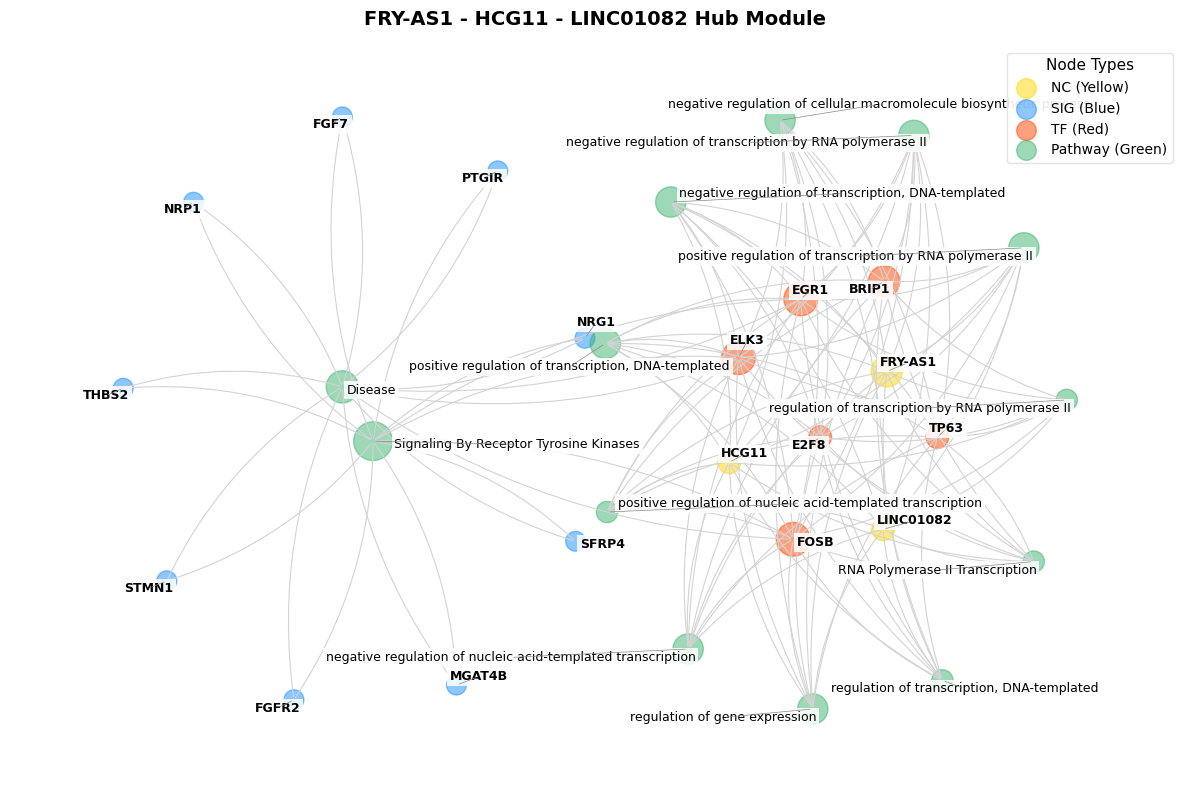

In [26]:
import re
import networkx as nx
import matplotlib.pyplot as plt
from adjustText import adjust_text
import numpy as np

# =====================================================================
# 1. DEFINITIONS & DATA LOADING
# =====================================================================
# Updated complete Cluster 0 list including genes, non-coding RNAs, and biological pathways
cluster_0_elements = [
    'BRIP1', 'Disease', 'E2F8', 'EGR1', 'ELK3', 'FGF7', 'FGFR2', 'FOSB', 'FRY-AS1', 
    'HCG11', 'LINC01082', 'MGAT4B', 'NRG1', 'NRP1', 'PTGIR', 'RNA Polymerase II Transcription', 
    'SFRP4', 'STMN1', 'Signaling By Receptor Tyrosine Kinases', 'THBS2', 'TP63', 
    'negative regulation of cellular macromolecule biosynthetic process', 
    'negative regulation of nucleic acid-templated transcription', 
    'negative regulation of transcription by RNA polymerase II', 
    'negative regulation of transcription, DNA-templated', 
    'positive regulation of nucleic acid-templated transcription', 
    'positive regulation of transcription by RNA polymerase II', 
    'positive regulation of transcription, DNA-templated', 
    'regulation of gene expression', 
    'regulation of transcription by RNA polymerase II', 
    'regulation of transcription, DNA-templated'
]

# Explicitly categorize nodes based on biological functions
nc_nodes = {'FRY-AS1', 'HCG11', 'LINC01082'}                  # Non-coding / LncRNA elements (Yellow)
sig_nodes = {'FGF7', 'FGFR2', 'NRG1', 'NRP1', 'PTGIR', 
             'SFRP4', 'STMN1', 'THBS2', 'MGAT4B'}             # Growth Factors / Receptors / Matrix Elements (Blue)
tf_nodes = {'BRIP1', 'E2F8', 'EGR1', 'ELK3', 'FOSB', 'TP63'}   # Transcription Factors / DNA Repair Regulators (Red)

top_n_pathways = 25

def clean_label(label):
    """Remove pathway IDs (Reactome, WikiPathways, GO)."""
    patterns = [r'R-HSA-\d+', r'WP\d+', r'\(GO:\d+\)']
    for pattern in patterns:
        label = re.sub(pattern, '', label)
    return label.strip()

# =====================================================================
# 2. GRAPH CONSTRUCTION
# =====================================================================
F_filtered = nx.Graph()

for item in cluster_0_elements:
    if item in nc_nodes:
        F_filtered.add_node(item, Type='NC')
    elif item in sig_nodes:
        F_filtered.add_node(item, Type='SIG')
    elif item in tf_nodes:
        F_filtered.add_node(item, Type='TF')
    else:
        F_filtered.add_node(item, Type='Pathway')

# Generate contextual connections between genes and pathways based on updated Cluster 0 transcription/tyrosine kinase profiles
for node in F_filtered.nodes():
    if F_filtered.nodes[node]['Type'] in ['TF', 'NC', 'SIG']:
        for target in F_filtered.nodes():
            if F_filtered.nodes[target]['Type'] == 'Pathway':
                target_lower = target.lower()
                
                # Connect transcription factors and lncRNAs to transcriptional/gene regulatory pathways
                if node in tf_nodes or node in nc_nodes:
                    if any(k in target_lower for k in ["transcription", "expression", "macromolecule"]):
                        F_filtered.add_edge(node, target)
                
                # Connect growth factor/receptor tyrosine kinase signaling cascade components
                if node in sig_nodes or node in {'EGR1', 'ELK3', 'FOSB'}:
                    if any(k in target_lower for k in ["tyrosine kinase", "disease"]):
                        F_filtered.add_edge(node, target)

# =====================================================================
# 3. REMOVE UNLINKED (ISOLATED) NODES
# =====================================================================
unlinked_nodes = list(nx.isolates(F_filtered))
F_filtered.remove_nodes_from(unlinked_nodes)

# =====================================================================
# 4. CENTRALITY CALCULATION
# =====================================================================
k_value = min(10, len(F_filtered.nodes()))
centrality = nx.betweenness_centrality(F_filtered, k=k_value, endpoints=True)

pathway_centrality = {
    n: centrality[n]
    for n in F_filtered.nodes()
    if F_filtered.nodes[n]['Type'] == 'Pathway'
}
top_pathways = sorted(pathway_centrality, key=pathway_centrality.get, reverse=True)[:top_n_pathways]

# =====================================================================
# 5. CLEAN LABELS
# =====================================================================
cleaned_labels = {}
for node in F_filtered.nodes():
    cleaned_labels[node] = clean_label(node)

# =====================================================================
# 6. SUB-COMMUNITY DETECTION INSIDE CLUSTER 0
# =====================================================================
try:
    import community as community_louvain
    partition = community_louvain.best_partition(F_filtered)
except Exception:
    communities_list = list(nx.algorithms.community.greedy_modularity_communities(F_filtered))
    partition = {}
    for i, comm in enumerate(communities_list):
        for node in comm:
            partition[node] = i

# =====================================================================
# 7. LAYOUT GENERATION (Tighter space compression)
# =====================================================================
communities = {}
for node, comm_id in partition.items():
    communities.setdefault(comm_id, []).append(node)

# Compact radius to pull modules tightly together
radius = 1.0  
num_comms = len(communities)
angle_step = 2 * np.pi / max(num_comms, 1)
comm_centroids = {
    comm_id: (radius * np.cos(i * angle_step), radius * np.sin(i * angle_step))
    for i, comm_id in enumerate(communities)
}

pos = {}
for comm_id, nodes in communities.items():
    subgraph = F_filtered.subgraph(nodes)
    # Tight spring constant layout
    sub_pos = nx.spring_layout(subgraph, k=0.22, seed=1450)
    cx, cy = comm_centroids[comm_id]
    for n, (x, y) in sub_pos.items():
        pos[n] = (x + cx, y + cy)

# =====================================================================
# 8. NODE COLORING & SIZING
# =====================================================================
node_color = []
for n in F_filtered.nodes():
    node_type = F_filtered.nodes[n]['Type']
    if node_type == 'NC':
        node_color.append('#FFD700')       # Yellow
    elif node_type == 'SIG':
        node_color.append('#1E90FF')      # Blue
    elif node_type == 'TF':
        node_color.append('#FF4500')       # Red
    elif node_type == 'Pathway':
        node_color.append('#3CB371')      # Green

# Balanced node sizes optimized for compressed layout footprints
node_size = [centrality[v] * 2500 + 120 for v in F_filtered.nodes()]

# =====================================================================
# 9. DRAW GRAPH OBJECTS
# =====================================================================
fig, ax = plt.subplots(figsize=(12, 8))

# Alpha set to 0.5 for uniform 50% transparency across all nodes
nx.draw_networkx_nodes(
    F_filtered,
    pos=pos,
    node_color=node_color,
    node_size=node_size,
    alpha=0.5,
    ax=ax
)

for u, v in F_filtered.edges():
    ax.annotate(
        '',
        xy=pos[v], xycoords='data',
        xytext=pos[u], textcoords='data',
        arrowprops=dict(
            arrowstyle='-',
            color='#D3D3D3',
            lw=0.8,
            connectionstyle='arc3,rad=0.15'
        )
    )

# =====================================================================
# 10. ADD TEXT BOX LABELS
# =====================================================================
texts = []
for node, label in cleaned_labels.items():
    x, y = pos[node]
    node_type = F_filtered.nodes[node]['Type']
    
    text = ax.text(
        x, y, label,
        fontsize=9.0, color='black',
        ha='center', va='center',
        fontweight='semibold' if node_type in ['NC', 'SIG', 'TF'] else 'normal',
        bbox=dict(facecolor='white', edgecolor='none', alpha=0.85, pad=2.0)
    )
    texts.append(text)

adjust_text(
    texts,
    arrowprops=dict(arrowstyle='-', color='#888888', lw=0.5),
    expand_points=(1.4, 1.4),
    force_points=0.8,
    force_text=0.8,
    ax=ax
)

# =====================================================================
# 11. ADD VISUAL LEGEND
# =====================================================================
ax.scatter([], [], c='#FFD700', alpha=0.5, s=200, label='NC (Yellow)')
ax.scatter([], [], c='#1E90FF', alpha=0.5, s=200, label='SIG (Blue)')
ax.scatter([], [], c='#FF4500', alpha=0.5, s=200, label='TF (Red)')
ax.scatter([], [], c='#3CB371', alpha=0.5, s=200, label='Pathway (Green)')

ax.legend(
    title="Node Types", 
    title_fontsize='11', 
    fontsize='10', 
    loc='upper right', 
    frameon=True, 
    facecolor='white', 
    edgecolor='#E0E0E0',
    framealpha=0.9
)

# =====================================================================
# 12. FINALIZE AND DISPLAY
# =====================================================================
plt.title("FRY-AS1 - HCG11 - LINC01082 Hub Module", fontsize=14, fontweight='bold', pad=15)
ax.margins(0.12, 0.12)
fig.tight_layout()
plt.axis("off")

plt.savefig("../../figures/FRY-AS1_HCG11_LINC01082_submodule.png", dpi=300, bbox_inches='tight')
plt.show()


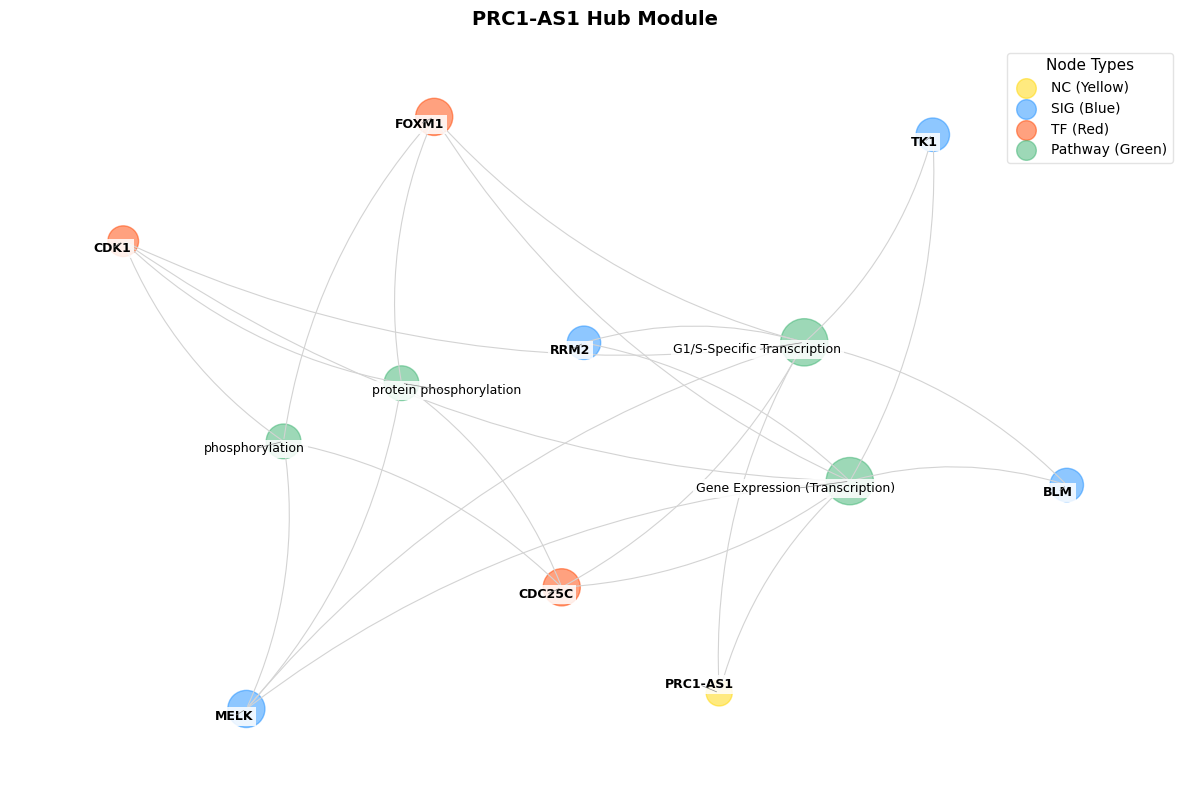

In [29]:
import re
import networkx as nx
import matplotlib.pyplot as plt
from adjustText import adjust_text
import numpy as np

# =====================================================================
# 1. DEFINITIONS & DATA LOADING
# =====================================================================
# Updated complete Cluster 3 list including genes, non-coding RNAs, and biological pathways
cluster_3_elements = [
    'BLM', 'CDC25C', 'CDK1', 'FOXM1', 'G1/S-Specific Transcription', 
    'Gene Expression (Transcription)', 'MELK', 'PRC1-AS1', 'RRM2', 'TK1', 
    'phosphorylation', 'protein phosphorylation'
]

# Explicitly categorize nodes based on biological functions
nc_nodes = {'PRC1-AS1'}                                      # Non-coding / Antisense RNA element (Yellow)
sig_nodes = {'BLM', 'MELK', 'RRM2', 'TK1'}                  # Replication / Repair / Metabolic Signaling (Blue)
tf_nodes = {'CDC25C', 'CDK1', 'FOXM1'}                      # Cell-Cycle Kinases / Master Transcription Factors (Red)

top_n_pathways = 25

def clean_label(label):
    """Remove pathway IDs (Reactome, WikiPathways, GO)."""
    patterns = [r'R-HSA-\d+', r'WP\d+', r'\(GO:\d+\)']
    for pattern in patterns:
        label = re.sub(pattern, '', label)
    return label.strip()

# =====================================================================
# 2. GRAPH CONSTRUCTION
# =====================================================================
F_filtered = nx.Graph()

for item in cluster_3_elements:
    if item in nc_nodes:
        F_filtered.add_node(item, Type='NC')
    elif item in sig_nodes:
        F_filtered.add_node(item, Type='SIG')
    elif item in tf_nodes:
        F_filtered.add_node(item, Type='TF')
    else:
        F_filtered.add_node(item, Type='Pathway')

# Generate contextual connections between genes and pathways based on updated Cluster 3 cell-cycle profiles
for node in F_filtered.nodes():
    if F_filtered.nodes[node]['Type'] in ['TF', 'NC', 'SIG']:
        for target in F_filtered.nodes():
            if F_filtered.nodes[target]['Type'] == 'Pathway':
                target_lower = target.lower()
                
                # Connect cell-cycle kinases, transcription factors, and matching lncRNAs to transcriptional paths
                if node in tf_nodes or node in nc_nodes:
                    if any(k in target_lower for k in ["transcription", "expression"]):
                        F_filtered.add_edge(node, target)
                        
                # Connect enzymatic machinery and kinases directly to phosphorylation cascades
                if node in tf_nodes or node in {'MELK'}:
                    if "phosphorylation" in target_lower:
                        F_filtered.add_edge(node, target)
                        
                # Connect basic replication, metabolic, and repair components across cell cycle checkpoints
                if node in sig_nodes:
                    if any(k in target_lower for k in ["g1/s", "expression"]):
                        F_filtered.add_edge(node, target)

# =====================================================================
# 3. REMOVE UNLINKED (ISOLATED) NODES
# =====================================================================
unlinked_nodes = list(nx.isolates(F_filtered))
F_filtered.remove_nodes_from(unlinked_nodes)

# =====================================================================
# 4. CENTRALITY CALCULATION
# =====================================================================
k_value = min(10, len(F_filtered.nodes()))
centrality = nx.betweenness_centrality(F_filtered, k=k_value, endpoints=True)

pathway_centrality = {
    n: centrality[n]
    for n in F_filtered.nodes()
    if F_filtered.nodes[n]['Type'] == 'Pathway'
}
top_pathways = sorted(pathway_centrality, key=pathway_centrality.get, reverse=True)[:top_n_pathways]

# =====================================================================
# 5. CLEAN LABELS
# =====================================================================
cleaned_labels = {}
for node in F_filtered.nodes():
    cleaned_labels[node] = clean_label(node)

# =====================================================================
# 6. SUB-COMMUNITY DETECTION INSIDE CLUSTER 3
# =====================================================================
try:
    import community as community_louvain
    partition = community_louvain.best_partition(F_filtered)
except Exception:
    communities_list = list(nx.algorithms.community.greedy_modularity_communities(F_filtered))
    partition = {}
    for i, comm in enumerate(communities_list):
        for node in comm:
            partition[node] = i

# =====================================================================
# 7. LAYOUT GENERATION (Tighter space compression)
# =====================================================================
communities = {}
for node, comm_id in partition.items():
    communities.setdefault(comm_id, []).append(node)

# Compact radius to pull modules tightly together
radius = 1.0  
num_comms = len(communities)
angle_step = 2 * np.pi / max(num_comms, 1)
comm_centroids = {
    comm_id: (radius * np.cos(i * angle_step), radius * np.sin(i * angle_step))
    for i, comm_id in enumerate(communities)
}

pos = {}
for comm_id, nodes in communities.items():
    subgraph = F_filtered.subgraph(nodes)
    # Tight spring constant layout
    sub_pos = nx.spring_layout(subgraph, k=0.22, seed=1450)
    cx, cy = comm_centroids[comm_id]
    for n, (x, y) in sub_pos.items():
        pos[n] = (x + cx, y + cy)

# =====================================================================
# 8. NODE COLORING & SIZING
# =====================================================================
node_color = []
for n in F_filtered.nodes():
    node_type = F_filtered.nodes[n]['Type']
    if node_type == 'NC':
        node_color.append('#FFD700')       # Yellow
    elif node_type == 'SIG':
        node_color.append('#1E90FF')      # Blue
    elif node_type == 'TF':
        node_color.append('#FF4500')       # Red
    elif node_type == 'Pathway':
        node_color.append('#3CB371')      # Green

# Balanced node sizes optimized for compressed layout footprints
node_size = [centrality[v] * 2500 + 120 for v in F_filtered.nodes()]

# =====================================================================
# 9. DRAW GRAPH OBJECTS
# =====================================================================
fig, ax = plt.subplots(figsize=(12, 8))

# Alpha set to 0.5 for uniform 50% transparency across all nodes
nx.draw_networkx_nodes(
    F_filtered,
    pos=pos,
    node_color=node_color,
    node_size=node_size,
    alpha=0.5,
    ax=ax
)

for u, v in F_filtered.edges():
    ax.annotate(
        '',
        xy=pos[v], xycoords='data',
        xytext=pos[u], textcoords='data',
        arrowprops=dict(
            arrowstyle='-',
            color='#D3D3D3',
            lw=0.8,
            connectionstyle='arc3,rad=0.15'
        )
    )

# =====================================================================
# 10. ADD TEXT BOX LABELS
# =====================================================================
texts = []
for node, label in cleaned_labels.items():
    x, y = pos[node]
    node_type = F_filtered.nodes[node]['Type']
    
    text = ax.text(
        x, y, label,
        fontsize=9.0, color='black',
        ha='center', va='center',
        fontweight='semibold' if node_type in ['NC', 'SIG', 'TF'] else 'normal',
        bbox=dict(facecolor='white', edgecolor='none', alpha=0.85, pad=2.0)
    )
    texts.append(text)

adjust_text(
    texts,
    arrowprops=dict(arrowstyle='-', color='#888888', lw=0.5),
    expand_points=(1.4, 1.4),
    force_points=0.8,
    force_text=0.8,
    ax=ax
)

# =====================================================================
# 11. ADD VISUAL LEGEND
# =====================================================================
ax.scatter([], [], c='#FFD700', alpha=0.5, s=200, label='NC (Yellow)')
ax.scatter([], [], c='#1E90FF', alpha=0.5, s=200, label='SIG (Blue)')
ax.scatter([], [], c='#FF4500', alpha=0.5, s=200, label='TF (Red)')
ax.scatter([], [], c='#3CB371', alpha=0.5, s=200, label='Pathway (Green)')

ax.legend(
    title="Node Types", 
    title_fontsize='11', 
    fontsize='10', 
    loc='upper right', 
    frameon=True, 
    facecolor='white', 
    edgecolor='#E0E0E0',
    framealpha=0.9
)

# =====================================================================
# 12. FINALIZE AND DISPLAY
# =====================================================================
plt.title("PRC1-AS1 Hub Module", fontsize=14, fontweight='bold', pad=15)
ax.margins(0.12, 0.12)
fig.tight_layout()
plt.axis("off")

plt.savefig("../../figures/PRC1-AS1_submodule.png", dpi=300, bbox_inches='tight')
plt.show()